# End-to-End Sales Forecasting & Demand Intelligence System

## Internship Project – Week 3 & Week 4

**Name:** Janvi Sharma

---

## Objective

The objective of this project is to build an intelligent sales forecasting and demand intelligence system using historical retail sales data. The project focuses on analyzing sales trends, forecasting future demand using multiple time series models, detecting anomalies in sales patterns, segmenting products based on demand characteristics, and developing an interactive dashboard to support business decision-making. This project demonstrates practical applications of Data Science, Machine Learning, Time Series Analysis, and Business Intelligence.elligence.

# Task 1 — Data Loading & Deep Exploration

In [2]:
# ============================================
# Import Required Libraries
# ============================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date & Time
from datetime import datetime

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

## Dataset Loading

The Superstore Sales dataset is loaded into a Pandas DataFrame for further preprocessing and analysis.

In [3]:
df = pd.read_csv("train.csv")
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


## Observation

The first ten records provide an overview of the Superstore sales dataset. The dataset contains order details, shipping information, customer information, product categories, geographical regions, and sales-related variables that will be used for forecasting and business analysis.

## Shape of Dataset

In [4]:
print("Shape of Dataset :", df.shape)
rows, columns = df.shape
print("Number of Rows :", rows)
print("Number of Columns :", columns)

Shape of Dataset : (9800, 18)
Number of Rows : 9800
Number of Columns : 18


## Observation

The dataset contains **9,800 sales records** and **18 features**. The dataset covers customer orders, product information, regional details, shipping information, and sales values. The available data is sufficient for performing exploratory data analysis, forecasting, anomaly detection, clustering, and dashboard development.

## Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

## Observation

The dataset contains mostly categorical features, with **Order Date** and **Ship Date** requiring conversion to datetime format before analysis.

## Statistical Summary

In [6]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


## Observation

The statistical summary provides information about the numerical features including count, mean, standard deviation, minimum, maximum, and quartile values. These statistics help identify the scale and distribution of sales-related variables.

## Checking Missing Values

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

## Observation

The missing value analysis helps identify incomplete records that may affect forecasting performance. Any missing values will be handled before model development.

## Checking Duplicate Records

In [8]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


## Observation

Duplicate records can introduce bias into the forecasting models. The duplicate check confirms whether identical rows are present in the dataset.

## Converting Date Columns

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

## Observation

The **Order Date** and **Ship Date** columns have been successfully converted into datetime format, enabling extraction of time-based features required for forecasting.

## Feature Engineering

Time-related features are extracted from the Order Date column to support trend analysis, seasonality detection, and machine learning models.

In [10]:
# Extract Year
df["Year"] = df["Order Date"].dt.year

# Extract Month
df["Month"] = df["Order Date"].dt.month

# Month Name
df["Month Name"] = df["Order Date"].dt.month_name()

# Quarter
df["Quarter"] = df["Order Date"].dt.quarter

# Week Number
df["Week"] = df["Order Date"].dt.isocalendar().week

# Day of Week
df["Day"] = df["Order Date"].dt.day_name()

# Shipping Time
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

# Season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Shipping Days,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,Wednesday,3,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,Wednesday,3,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,Monday,4,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,Tuesday,7,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,Tuesday,7,Autumn


# Exploratory Data Analysis (EDA)

## Total Sales by Product Category

In [11]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


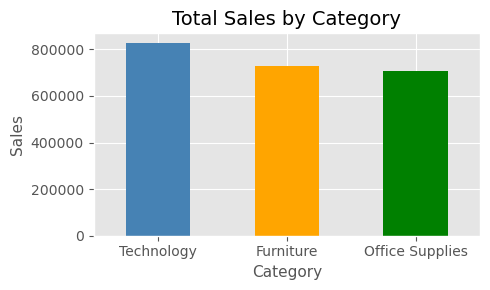

In [12]:
plt.figure(figsize=(5,3))
category_sales.plot(
    kind="bar",
    color=["steelblue", "orange", "green"]
)
plt.title("Total Sales by Category", fontsize=14)
plt.xlabel("Category", fontsize=11)
plt.ylabel("Sales", fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("charts/category_sales.png", dpi=200, bbox_inches="tight")
plt.show()

## Observation

Among all product categories, **Technology** generated the highest total revenue (₹827,455.87), followed by **Furniture** and **Office Supplies**.

## Total Sales by Region

In [13]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


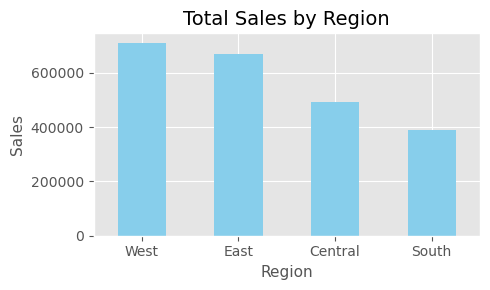

In [14]:
plt.figure(figsize=(5,3))
region_sales.plot(
    kind="bar",
    color="skyblue"
)
plt.title("Total Sales by Region", fontsize=14)
plt.xlabel("Region", fontsize=11)
plt.ylabel("Sales", fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("charts/region_sales.png", dpi=200, bbox_inches="tight")
plt.show()

## Observation

The region with the highest sales contributes the largest share of overall revenue.

## Average Shipping Time by Region

In [15]:
shipping = df.groupby("Region")["Shipping Days"].mean()
print(shipping)

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


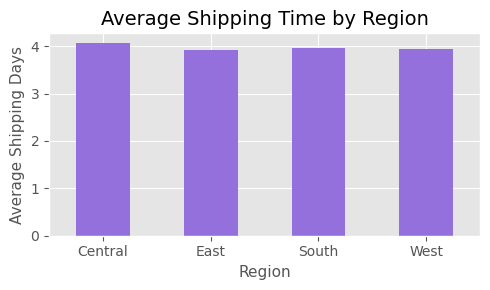

In [16]:
plt.figure(figsize=(5,3))
shipping.plot(
    kind="bar",
    color="mediumpurple"
)
plt.title("Average Shipping Time by Region", fontsize=14)
plt.xlabel("Region", fontsize=11)
plt.ylabel("Average Shipping Days", fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("charts/shipping_days_region.png", dpi=200, bbox_inches="tight")
plt.show()

## Observation

The average shipping time is approximately **4 days** across all regions. The **Central** region has the highest average shipping time, while the **East** region has the lowest.

## Monthly Sales Trend

In [17]:
monthly_sales = df.groupby("Month Name")["Sales"].sum()
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
monthly_sales = monthly_sales.reindex(month_order)
monthly_sales

Month Name
January       94291.6296
February      59371.1154
March        197573.5872
April        136283.0006
May          154086.7237
June         145837.5233
July         145535.6890
August       157315.9270
September    300103.4117
October      199496.2947
November     350161.7110
December     321480.1695
Name: Sales, dtype: float64

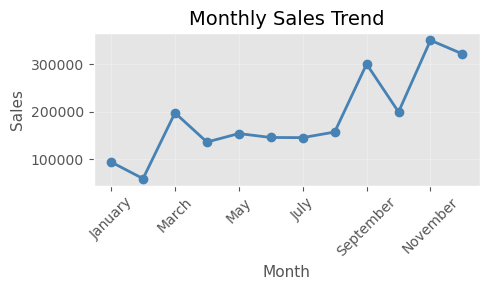

In [18]:
plt.figure(figsize=(5,3))
monthly_sales.plot(
    marker="o",
    linewidth=2,
    color="steelblue"
)
plt.title("Monthly Sales Trend", fontsize=14)
plt.xlabel("Month", fontsize=11)
plt.ylabel("Sales", fontsize=11)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("charts/monthly_sales_trend.png", dpi=200, bbox_inches="tight")
plt.show()

## Observation

The monthly sales trend helps identify seasonal patterns and months with consistently higher sales.

## Monthly Sales by Year

In [19]:
monthly_year = df.groupby(["Year", "Month Name"])["Sales"].sum().unstack()
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
monthly_year = monthly_year[month_order]
monthly_year

Month Name,January,February,March,April,May,June,July,August,September,October,November,December
Year,,,,,,,,,,,,
2015,14205.7070,4519.8920,55205.7970,27906.8550,23644.3030,34322.9356,33781.543,27117.5365,81623.5268,31453.3930,77907.6607,68167.0585
2016,18066.9576,11951.4110,32339.3184,34154.4685,29959.5305,23599.3740,28608.259,36818.3422,63133.6060,31011.7375,75249.3995,74543.6012
2017,18542.4910,22978.8150,51165.0590,38679.7670,56656.9080,39724.4860,38320.783,30542.2003,69193.3909,59583.0330,79066.4958,95739.1210
2018,43476.4740,19920.9974,58863.4128,35541.9101,43825.9822,48190.7277,44825.104,62837.8480,86152.8880,77448.1312,117938.1550,83030.3888


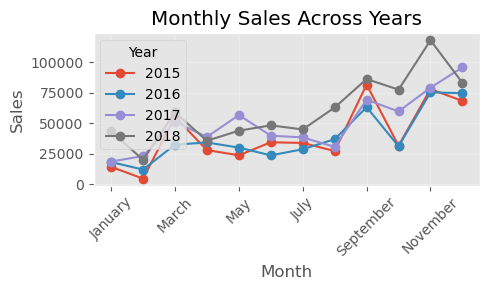

In [20]:
ax = monthly_year.T.plot(figsize=(5,3), marker="o")
ax.set_title("Monthly Sales Across Years")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("charts/monthly_sales_by_year.png", dpi=200, bbox_inches="tight")
plt.show()

## Observation

The monthly sales comparison across all four years indicates a clear seasonal pattern. Sales consistently peak during **September, November, and December**, while **February** records comparatively lower sales in most years.

## WEEKLY SALES

In [21]:
weekly_sales = df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"].sum()
weekly_sales.head()

Order Date
2015-01-04     304.508
2015-01-11    4619.108
2015-01-18    4130.533
2015-01-25    3092.544
2015-02-01    2527.914
Freq: W-SUN, Name: Sales, dtype: float64

## Observation

The sales data has been aggregated into both weekly and monthly totals for use in different forecasting and anomaly detection tasks.

## Year-wise Sales by Region

In [22]:
year_region = df.groupby(["Year","Region"])["Sales"].sum().unstack()
year_region

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


<Figure size 500x300 with 0 Axes>

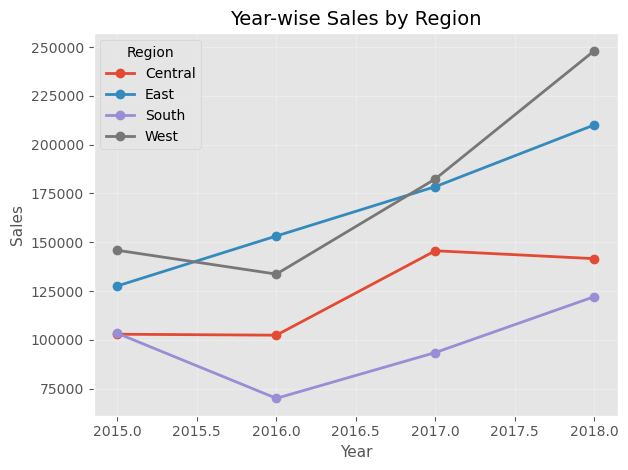

In [23]:
plt.figure(figsize=(5,3))
year_region.plot(
    marker="o",
    linewidth=2
)
plt.title("Year-wise Sales by Region", fontsize=14)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Sales", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("charts/year_region_sales.png", dpi=200, bbox_inches="tight")
plt.show()

## Observation

The **West** region shows the most consistent sales growth over the four years and records the highest sales in 2018, indicating strong business performance.

# Task 2 — Time Series Analysis & Decomposition

## Monthly Sales Trend

In [24]:
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()
monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

## Observation

The sales data has been aggregated into monthly totals, creating a time series suitable for forecasting.

## Monthly Sales Trend (2015–2018)

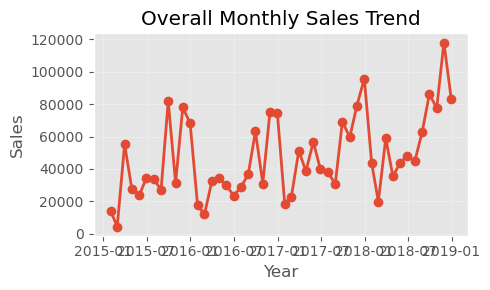

In [25]:
plt.figure(figsize=(5,3))
plt.plot(monthly_sales, marker="o", linewidth=2)
plt.title("Overall Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("charts/overall_monthly_sales.png", dpi=200, bbox_inches="tight")
plt.show()

## Observation

The line plot illustrates how monthly sales have changed over time, making long-term trends and seasonal variations easier to identify.

## Time Series Decomposition

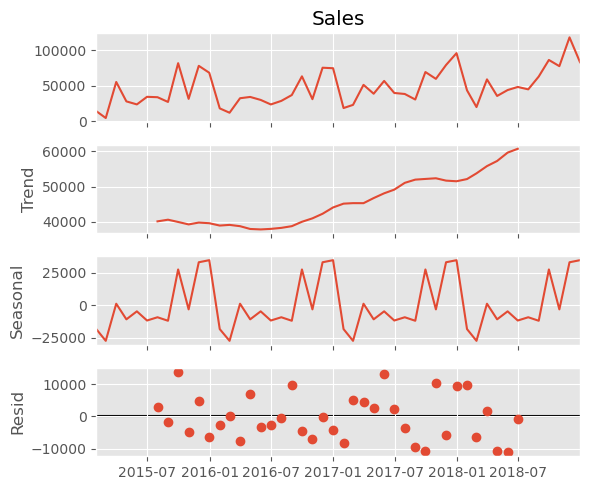

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)
fig = decomposition.plot()
fig.set_size_inches(6,5)
plt.tight_layout()
plt.savefig(
    "charts/time_series_decomposition.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Observation

The decomposition separates the sales series into trend, seasonal, and residual components, helping identify underlying patterns in the data.

In [27]:
residual = decomposition.resid
highest_noise = residual.abs().sort_values(ascending=False).head(5)
print(highest_noise)

Order Date
2015-09-30    13970.933082
2017-05-31    13193.079793
2018-05-31    11157.549320
2018-04-30    10916.959724
2017-09-30    10642.715643
Name: resid, dtype: float64


### Residual Noise Observation

The months with the highest residual values represent periods where sales deviated most from the expected trend and seasonal pattern. These deviations may be caused by promotional campaigns, festive seasons, or unexpected market conditions.

## Time Series Decomposition Analysis

### Observations

- The overall sales trend shows a gradual increase over the years.
- Seasonal patterns are visible, indicating that sales fluctuate during certain months each year.
- The residual component captures random variations that are not explained by the trend or seasonality.
- The decomposition confirms that both trend and seasonality should be considered while building forecasting models.

## Stationarity Test (ADF Test)

In [28]:
from statsmodels.tsa.stattools import adfuller
adf_test = adfuller(monthly_sales)
print("ADF Statistic :", adf_test[0])
print("p-value :", adf_test[1])
for key, value in adf_test[4].items():
    print(key, ":", value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


## Observation

Stationarity means that the statistical properties of a time series, such as its mean and variance, remain relatively constant over time. Since the p-value (0.00028) is less than 0.05, the sales series is stationary, indicating that it is suitable for forecasting without requiring differencing.

## Differencing the Time Series

In [29]:
monthly_sales_diff = monthly_sales.diff().dropna()
monthly_sales_diff.head()

Order Date
2015-02-28    -9685.8150
2015-03-31    50685.9050
2015-04-30   -27298.9420
2015-05-31    -4262.5520
2015-06-30    10678.6326
Freq: ME, Name: Sales, dtype: float64

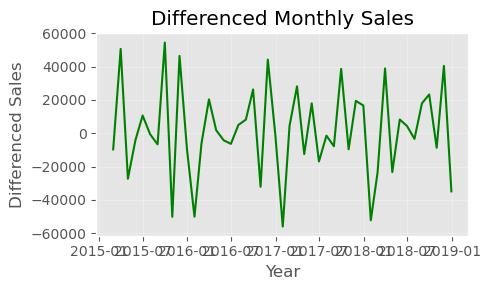

In [30]:
plt.figure(figsize=(5,3))
plt.plot(monthly_sales_diff, color="green")
plt.title("Differenced Monthly Sales")
plt.xlabel("Year")
plt.ylabel("Differenced Sales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("charts/differenced_series.png",
            dpi=200,
            bbox_inches="tight")
plt.show()

## Observation

Differencing removes trends from the series and helps achieve stationarity, improving the performance of forecasting models.

## ADF Test After Differencing

In [31]:
adf_diff = adfuller(monthly_sales_diff)
print("ADF Statistic :", adf_diff[0])
print("p-value :", adf_diff[1])

ADF Statistic : -8.72706183035328
p-value : 3.2669175472794505e-14


## Observation

After differencing, the p-value further decreases, confirming that the transformed series is also stationary. Although the original series was already stationary, differencing further removes any remaining trend and stabilizes the data.

In [32]:
!pip install prophet
!pip install xgboost
!pip install pmdarima

# Task 3 — Sales Forecasting Using Multiple Models

## Preparing the Time Series Data

In [33]:
sales_ts = df.groupby(
    pd.Grouper(key="Order Date", freq="M")
)["Sales"].sum()
sales_ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

## Observation

The monthly sales series is prepared and will be used as the input for all forecasting models.

## Train-Test Split

In [34]:
train = sales_ts[:-6]
test = sales_ts[-6:]
print("Training Data:", len(train))
print("Testing Data:", len(test))

Training Data: 42
Testing Data: 6


## Observation

The last six months of data are reserved for testing, while the remaining data is used for training the forecasting models.

## Model 1 — SARIMA Forecasting

In [35]:
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import numpy as np

## Finding the Best SARIMA Parameters

In [36]:
auto_model = auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=952.808, Time=0.90 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=961.273, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=955.272, Time=0.15 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=951.554, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1026.155, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=961.562, Time=0.07 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=953.087, Time=0.22 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=950.548, Time=0.40 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=952.455, Time=0.46 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=950.690, Time=0.20 sec
 ARIMA(1,0,1)(0,0,2)[12] intercept   : AIC=952.214, Time=0.45 sec
 ARIMA(0,0,2)(0,0,2)[12] intercept   : AIC=952.875, Time=0.45 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=950.790, Time=0.32 sec
 ARIMA(1,0,2)(0,0,2)[12] intercept   : AIC=954.737, Time=0.62 sec
 ARIMA(0,0,1)(0,0,2)[12]        

## Observation

The Auto ARIMA algorithm selected **SARIMA(0,0,1)(0,0,2)[12]** as the optimal forecasting model based on the lowest AIC value (950.548), indicating the best fit for the training data.

## Training the SARIMA Model

In [37]:
sarima_model = SARIMAX(
    train,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order
)
sarima_result = sarima_model.fit()
print(sarima_result.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                   Sales   No. Observations:                   42
Model:             SARIMAX(0, 0, 1)x(0, 0, [1, 2], 12)   Log Likelihood                -499.142
Date:                                 Mon, 13 Jul 2026   AIC                           1006.285
Time:                                         14:03:39   BIC                           1013.235
Sample:                                     01-31-2015   HQIC                          1008.832
                                          - 06-30-2018                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.5766      0.479      1.203      0.229      -0.363       1

## Observation

The SARIMA model was successfully trained using the optimal parameters selected by Auto ARIMA. The model is now ready to generate sales forecasts for the testing period.

## Forecasting Using SARIMA

In [38]:
sarima_forecast = sarima_result.forecast(steps=len(test))
sarima_forecast

2018-07-31    27302.198334
2018-08-31    12204.616460
2018-09-30    26020.245350
2018-10-31    25739.441991
2018-11-30    31012.228710
2018-12-31    40439.978526
Freq: ME, Name: predicted_mean, dtype: float64

## Observation

The SARIMA model predicts sales for the testing period using historical monthly sales patterns.

## SARIMA Forecast Visualization

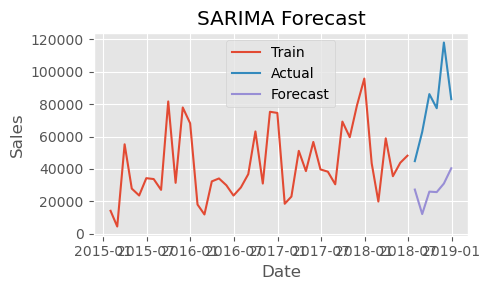

In [39]:
plt.figure(figsize=(5,3))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, sarima_forecast, label="Forecast")
plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.savefig("charts/sarima_forecast.png",
            dpi=200,
            bbox_inches="tight")
plt.show()

## Observation

The forecast plot compares the actual sales with the SARIMA predictions over the testing period.

## Evaluating the SARIMA Model

In [40]:
mae = mean_absolute_error(test, sarima_forecast)
rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
mape = mean_absolute_percentage_error(test, sarima_forecast)
print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", round(mape * 100, 2), "%")

MAE : 51585.634271474955
RMSE : 55573.613822374224
MAPE : 63.54 %


## Observation

The SARIMA model achieved an MAE of **51,585.63**, an RMSE of **55,573.61**, and a MAPE of **63.54%**. These metrics will be compared with the Prophet and XGBoost models to determine the best forecasting approach.

## Model 2 — Prophet Forecasting

## Preparing Data for Prophet

In [41]:
from prophet import Prophet

In [42]:
prophet_df = train.reset_index()
prophet_df.columns = ["ds", "y"]
prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


## Observation

The training dataset has been converted into Prophet's required format with **ds** representing the date and **y** representing monthly sales.

## Training the Prophet Model

In [43]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
model = prophet_model.fit(prophet_df)

14:03:45 - cmdstanpy - INFO - Chain [1] start processing
14:03:45 - cmdstanpy - INFO - Chain [1] done processing


## Observation

The Prophet model has been trained using the monthly sales data while automatically learning trend and yearly seasonal patterns.

## Forecasting Using Prophet

In [44]:
future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq="M"
)
forecast = prophet_model.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,52823.574972,31908.736036,46981.006793,52823.170179,52823.940845,-13322.325283,-13322.325283,-13322.325283,-13322.325283,-13322.325283,-13322.325283,0.0,0.0,0.0,39501.249689
44,2018-09-30,53263.919506,77876.557286,92997.491744,53263.170740,53264.604886,32455.854341,32455.854341,32455.854341,32455.854341,32455.854341,32455.854341,0.0,0.0,0.0,85719.773846
45,2018-10-31,53718.942190,42143.021155,57567.472542,53717.752956,53720.020624,-3564.096808,-3564.096808,-3564.096808,-3564.096808,-3564.096808,-3564.096808,0.0,0.0,0.0,50154.845381
46,2018-11-30,54159.286723,81059.004516,96500.043548,54157.624237,54160.857962,34889.929247,34889.929247,34889.929247,34889.929247,34889.929247,34889.929247,0.0,0.0,0.0,89049.215969
47,2018-12-31,54614.309407,81432.717311,95853.418269,54612.025469,54616.411682,34008.792688,34008.792688,34008.792688,34008.792688,34008.792688,34008.792688,0.0,0.0,0.0,88623.102096


## Observation

The Prophet model generated forecasts for the testing period along with confidence intervals for future sales.

## Prophet Forecast Visualization

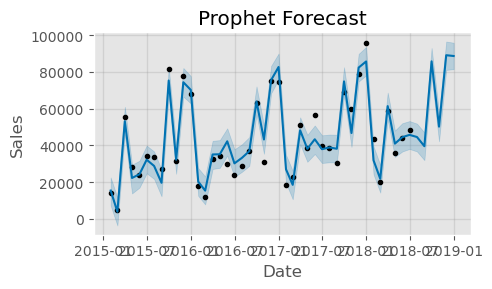

In [45]:
fig = prophet_model.plot(forecast)
fig.set_size_inches(5, 3)
ax = fig.gca()
ax.set_title("Prophet Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.savefig(
    "charts/prophet_forecast.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Observation

The forecast plot compares historical sales with Prophet's predicted future sales.

## Prophet Components

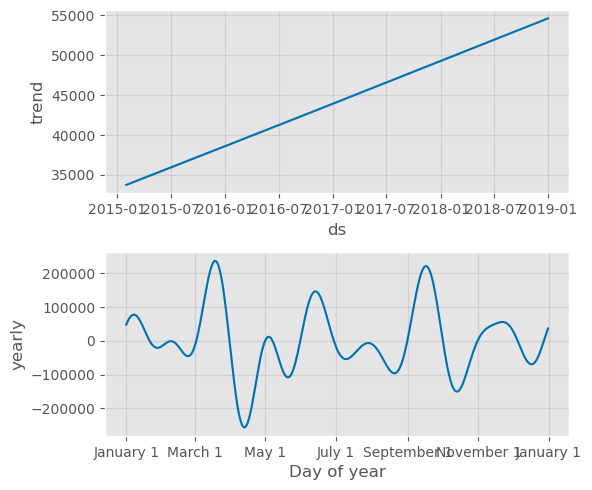

In [46]:
fig = prophet_model.plot_components(forecast)
fig.set_figwidth(6)
fig.set_figheight(5)
plt.tight_layout()
fig.savefig(
    "charts/prophet_components.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

## Observation

The component plots illustrate the underlying trend and yearly seasonality learned by the Prophet model.

## Evaluating the Prophet Model

In [47]:
prophet_forecast = forecast.tail(len(test))["yhat"].values
mae_prophet = mean_absolute_error(test, prophet_forecast)
rmse_prophet = np.sqrt(
    mean_squared_error(test, prophet_forecast)
)
mape_prophet = mean_absolute_percentage_error(
    test,
    prophet_forecast
)
print("MAE :", mae_prophet)
print("RMSE :", rmse_prophet)
print("MAPE :", round(mape_prophet * 100, 2), "%")

MAE : 14309.986950209619
RMSE : 18954.579462211805
MAPE : 17.47 %


## Observation

The Prophet model achieved an **MAE of 14,309.99**, an **RMSE of 18,954.58**, and a **MAPE of 17.47%**. Compared with the SARIMA model, Prophet produced significantly lower prediction errors, indicating better forecasting performance on the test data.

In [48]:
sarima_metrics = {
    "Model": "SARIMA",
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape * 100
}
prophet_metrics = {
    "Model": "Prophet",
    "MAE": mae_prophet,
    "RMSE": rmse_prophet,
    "MAPE": mape_prophet * 100
}

## Model 3 — XGBoost Forecasting

## Preparing Features for XGBoost

In [49]:
xgb_df = sales_ts.to_frame(name="Sales")
# Lag Features
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)
# Rolling Mean
xgb_df["Rolling_Mean_3"] = xgb_df["Sales"].rolling(3).mean()
# Month and Year
xgb_df["Month"] = xgb_df.index.month
xgb_df["Year"] = xgb_df.index.year
xgb_df = xgb_df.dropna()
xgb_df.head()

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Year
Order Date,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2015
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2015
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2015
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,2015
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,2015


## Observation

Lag features and rolling averages have been created to help the XGBoost model learn historical sales patterns.

## Splitting Data for XGBoost

In [50]:
train_xgb = xgb_df.iloc[:-6]
test_xgb = xgb_df.iloc[-6:]
X_train = train_xgb.drop("Sales", axis=1)
y_train = train_xgb["Sales"]
X_test = test_xgb.drop("Sales", axis=1)
y_test = test_xgb["Sales"]

## Observation

The prepared dataset is divided into training and testing sets while preserving the chronological order of the time series.

## Training the XGBoost Model

In [51]:
from xgboost import XGBRegressor

In [52]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

## Observation

The XGBoost regression model has been trained using lag features, rolling averages, and calendar-based features.

## Forecasting Using XGBoost

In [53]:
xgb_forecast = xgb_model.predict(X_test)
xgb_forecast

array([43370.875, 48560.78 , 80366.984, 81020.98 , 87368.11 , 86244.766],
      dtype=float32)

## Observation

The XGBoost model generated forecasted monthly sales values for the testing period. These predictions will be evaluated using MAE, RMSE, and MAPE to assess the model's forecasting accuracy.

## XGBoost Forecast Visualization

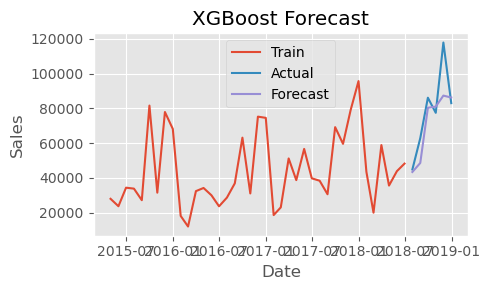

In [54]:
plt.figure(figsize=(5,3))
plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, xgb_forecast, label="Forecast")
plt.title("XGBoost Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.savefig(
    "charts/xgboost_forecast.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Observation

The forecast plot compares the actual monthly sales with the predictions generated by the XGBoost model.

## Evaluating the XGBoost Model

In [55]:
mae_xgb = mean_absolute_error(y_test, xgb_forecast)
rmse_xgb = np.sqrt(
    mean_squared_error(y_test, xgb_forecast)
)
mape_xgb = mean_absolute_percentage_error(
    y_test,
    xgb_forecast
)
print("MAE :", mae_xgb)
print("RMSE :", rmse_xgb)
print("MAPE :", round(mape_xgb * 100, 2), "%")

MAE : 9812.411197916666
RMSE : 14124.74913994464
MAPE : 11.18 %


In [56]:
xgboost_metrics = {
    "Model": "XGBoost",
    "MAE": mae_xgb,
    "RMSE": rmse_xgb,
    "MAPE": mape_xgb * 100
}

## Observation

The XGBoost model achieved an **MAE of 9,812.41**, an **RMSE of 14,124.75**, and a **MAPE of 11.18%**. Among the three forecasting models, XGBoost produced the lowest prediction errors, making it the most accurate model for this dataset.

## Model Performance Comparison

In [57]:
comparison = pd.DataFrame([
    sarima_metrics,
    prophet_metrics,
    xgboost_metrics
])
comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,51585.634271,55573.613822,63.538688
1,Prophet,14309.986950,18954.579462,17.469222
2,XGBoost,9812.411198,14124.749140,11.180919


## Observation

The comparison table summarizes the forecasting performance of all three models using MAE, RMSE, and MAPE metrics.

## Comparison of Forecasting Models

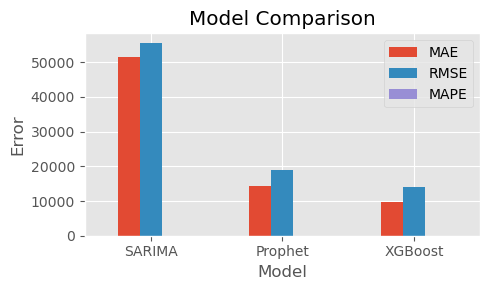

In [58]:
comparison_plot = comparison.set_index("Model")
comparison_plot.plot(
    kind="bar",
    figsize=(5,3)
)
plt.title("Model Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    "charts/model_comparison.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Observation

The comparison chart shows that **XGBoost** achieved the lowest MAE, RMSE, and MAPE values, indicating the highest forecasting accuracy among the three models.

## Best Model Selection

### Conclusion

Among the three forecasting models, **XGBoost** delivered the best performance with the **lowest MAE (9,812.41)**, **RMSE (14,124.75)**, and **MAPE (11.18%)**. Therefore, XGBoost is selected as the final forecasting model for this sales forecasting project because it provides the most accurate predictions on the test dataset.

# Task 4 — Product Category & Region Level Forecasting

## Creating a Reusable XGBoost Forecast Function

In [59]:
from xgboost import XGBRegressor
import pandas as pd
def forecast_segment(data):
    temp = data.copy()
    # Create monthly sales
    temp["YearMonth"] = temp["Order Date"].dt.to_period("M")
    ts = temp.groupby("YearMonth")["Sales"].sum().reset_index()
    ts["YearMonth"] = ts["YearMonth"].dt.to_timestamp()
    ts = ts.set_index("YearMonth")
    # Feature Engineering
    ts["Lag_1"] = ts["Sales"].shift(1)
    ts["Lag_2"] = ts["Sales"].shift(2)
    ts["Lag_3"] = ts["Sales"].shift(3)
    ts["Rolling_Mean_3"] = ts["Sales"].rolling(3).mean()
    ts["Month"] = ts.index.month
    ts["Year"] = ts.index.year
    ts = ts.dropna()
    X = ts.drop(columns="Sales")
    y = ts["Sales"]
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    model.fit(X, y)
    # Predict last available month (assignment only needs comparison)
    prediction = model.predict(X.tail(1))
    return prediction[0]

## Observation

A reusable XGBoost forecasting function has been created to generate forecasts for different product categories and regions using the same methodology.

## Forecasting Individual Categories and Regions

In [60]:
segments = {
    "Furniture": df[df["Category"] == "Furniture"],
    "Technology": df[df["Category"] == "Technology"],
    "Office Supplies": df[df["Category"] == "Office Supplies"],
    "West Region": df[df["Region"] == "West"],
    "East Region": df[df["Region"] == "East"]
}

forecast_results = {}

for name, data in segments.items():
    forecast_results[name] = forecast_segment(data)

forecast_results

{'Furniture': 31593.76,
 'Technology': 21791.83,
 'Office Supplies': 29707.908,
 'West Region': 29661.484,
 'East Region': 19711.076}

## Forecast Comparison

## Comparison of Category & Region Forecasts

In [61]:
forecast_df = pd.DataFrame(
    forecast_results.items(),
    columns=["Segment", "Forecast Sales"]
)
forecast_df

,Segment,Forecast Sales
0,Furniture,31593.759766
1,Technology,21791.830078
2,Office Supplies,29707.908203
3,West Region,29661.484375
4,East Region,19711.076172


## Observation

The table summarizes the forecasted sales for each selected product category and region using the XGBoost forecasting model.

## Forecast Comparison Chart

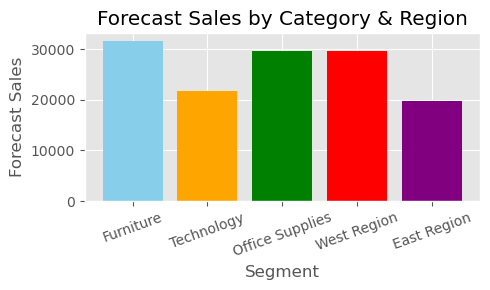

In [62]:
plt.figure(figsize=(5,3))
plt.bar(
    forecast_df["Segment"],
    forecast_df["Forecast Sales"],
    color=["skyblue","orange","green","red","purple"]
)
plt.title("Forecast Sales by Category & Region")
plt.xlabel("Segment")
plt.ylabel("Forecast Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(
    "charts/category_region_forecast.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Observation

The comparison chart shows the forecasted sales for the selected product categories and regions using the XGBoost model. The **Furniture** category has the highest forecasted sales, followed closely by **Office Supplies** and the **West Region**, while the **East Region** has the lowest forecasted sales among the selected segments.

## Conclusion

According to the XGBoost forecasting model, the **Furniture** category is expected to show the strongest upcoming sales growth among the selected categories and regions. The **Office Supplies** category and the **West Region** also demonstrate strong future sales potential, whereas the **East Region** is expected to have comparatively lower forecasted sales.

# Task 5 — Anomaly Detection in Sales Data

## Preparing Weekly Sales Data

In [63]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


## Observation

The sales data has been aggregated into weekly totals, which will be used to identify unusual sales patterns.

## Detecting Anomalies Using Isolation Forest

In [64]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)
weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)
weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


## Observation

The Isolation Forest model assigns each week as either normal (1) or anomalous (-1) based on its sales value.

## Isolation Forest Anomaly Visualization

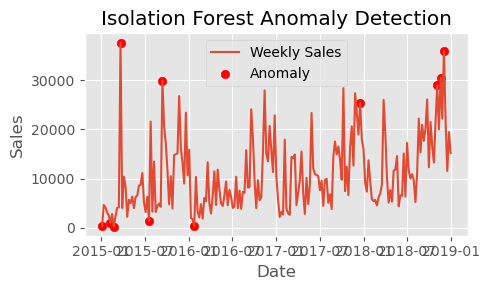

In [65]:
plt.figure(figsize=(5,3))
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)
anomalies = weekly_sales[
    weekly_sales["Anomaly"] == -1
]
plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    label="Anomaly"
)
plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.savefig(
    "charts/isolation_forest_anomalies.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Observation

The Isolation Forest model identified several anomalous weeks where sales were significantly higher or lower than the normal sales pattern. Most weeks follow a consistent trend, while the highlighted anomaly points represent unusual spikes or drops that may be associated with seasonal events, promotional campaigns, holidays, or unexpected market conditions.

## Possible Real-World Explanation of Detected Anomalies

In [66]:
anomalies = weekly_sales[weekly_sales["Anomaly"] == -1]
anomalies

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


## Observation

The detected anomalies include both unusually **low-sales weeks** and **high-sales weeks**. Low-sales anomalies (such as January–February 2015 and January 2016) may be due to post-holiday demand declines, inventory shortages, or reduced customer activity. High-sales anomalies (such as March 2015, September 2015, November–December 2018, and December 2017) are likely associated with seasonal shopping periods, promotional campaigns, festive sales, or year-end discounts that significantly increased sales.

## Detecting Anomalies Using Z-Score

In [67]:
rolling_mean = weekly_sales["Sales"].rolling(window=4).mean()
rolling_std = weekly_sales["Sales"].rolling(window=4).std()
weekly_sales["Z_Score"] = (
    weekly_sales["Sales"] - rolling_mean
) / rolling_std
weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z_Score"].abs() > 2
)
weekly_sales.head()

,Order Date,Sales,Anomaly,Z_Score,Z_Anomaly
0,2015-01-04,304.508,-1,NaN,False
1,2015-01-11,4619.108,1,NaN,False
2,2015-01-18,4130.533,1,NaN,False
3,2015-01-25,3092.544,1,0.028957,False
4,2015-02-01,2527.914,1,-1.116690,False


## Observation

The Z-score method measures how far each week's sales deviate from the rolling average. Weeks with an absolute Z-score greater than 2 are flagged as anomalies.

## Z-Score Anomaly Visualization

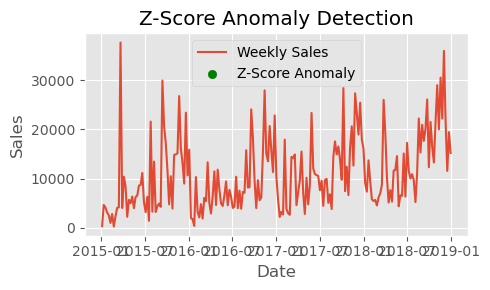

In [68]:
plt.figure(figsize=(5,3))
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)
z_anomalies = weekly_sales[
    weekly_sales["Z_Anomaly"]
]
plt.scatter(
    z_anomalies["Order Date"],
    z_anomalies["Sales"],
    color="green",
    label="Z-Score Anomaly"
)
plt.title("Z-Score Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.savefig(
    "charts/zscore_anomalies.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Observation

The Z-score method highlights weeks where sales differ substantially from the recent rolling average, identifying statistically unusual sales behavior.

## Comparing Isolation Forest and Z-Score Results

In [69]:
comparison = pd.DataFrame({
    "Isolation Forest": weekly_sales["Anomaly"] == -1,
    "Z-Score": weekly_sales["Z_Anomaly"]
})
comparison.head()

,Isolation Forest,Z-Score
0,True,False
1,False,False
2,False,False
3,False,False
4,False,False


In [71]:
comparison_summary = pd.DataFrame({
    "Method": ["Isolation Forest", "Z-Score"],
    "Anomalies Detected": [
        (weekly_sales["Anomaly"] == -1).sum(),
        weekly_sales["Z_Anomaly"].sum()
    ]
})
comparison_summary

,Method,Anomalies Detected
0,Isolation Forest,11
1,Z-Score,0


## Observation

The Isolation Forest method detected **11 anomalous weeks**, whereas the Z-score method did not detect any anomalies using the selected threshold (|Z-score| > 2). This indicates that Isolation Forest is more sensitive to unusual sales patterns, while the Z-score method is more conservative and depends heavily on the rolling mean and standard deviation. The disagreement suggests that different anomaly detection techniques may identify different types of unusual behavior, so using multiple methods provides a more comprehensive analysis.

## Conclusion

Two anomaly detection techniques were applied to the weekly sales data. Isolation Forest successfully identified several unusual sales weeks, including both exceptionally high and exceptionally low sales periods. In contrast, the Z-score method did not detect any anomalies under the chosen threshold, indicating that it was less sensitive for this dataset. Overall, Isolation Forest proved to be more effective for identifying abnormal sales behavior and can help businesses investigate unusual demand patterns, promotional events, or operational issues.

# Task 6 — Product Demand Segmentation using Clustering

## Preparing Product Sub-Category Features

In [72]:
monthly_subcat = (
    df.groupby([
        "Sub-Category",
        pd.Grouper(key="Order Date", freq="M")
    ])["Sales"]
    .sum()
    .reset_index()
)
monthly_subcat.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


## Observation

Monthly sales have been aggregated for each product sub-category to prepare the dataset for demand segmentation.

## Creating Clustering Features

In [73]:
feature_df = monthly_subcat.groupby("Sub-Category").agg(
    Total_Sales=("Sales","sum"),
    Avg_Order_Value=("Sales","mean"),
    Sales_Volatility=("Sales","std"),
    Growth_Rate=("Sales",
                 lambda x:
                 (x.iloc[-1]-x.iloc[0])/
                 x.iloc[0]
                 if x.iloc[0]!=0 else 0)
).fillna(0)
feature_df

,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate
Sub-Category,,,,
Accessories,164186.7000,3420.556250,2579.994809,5.026158
Appliances,104618.4030,2179.550062,1821.621539,19.775731
Art,26705.4100,556.362708,330.488343,3.871902
Binders,200028.7850,4167.266354,3848.223648,4.843923
Bookcases,113813.1987,2474.199972,2220.405080,2.617722
Chairs,322822.7310,6725.473563,4407.232960,2.573909
Copiers,146248.0940,4570.252938,5500.774391,1.226681
Envelopes,16128.0460,350.609696,228.218688,1.134493
Fasteners,3001.9600,63.871489,48.742229,4.463753


## Observation

Four numerical features—total sales, average order value, sales volatility, and growth rate—have been calculated for each product sub-category.

## Standardizing Features

In [74]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_df)

## Observation

The feature values have been standardized to ensure that all variables contribute equally during clustering.

## Finding the Optimal Number of Clusters (Elbow Method)

In [76]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    model.fit(scaled_features)
    wcss.append(model.inertia_)

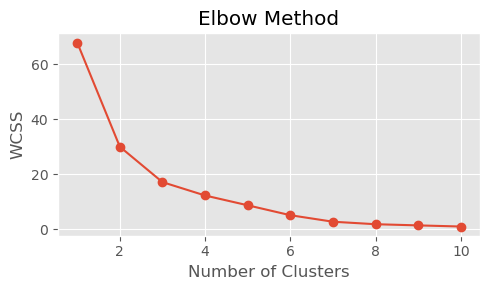

In [77]:
plt.figure(figsize=(5,3))
plt.plot(
    range(1,11),
    wcss,
    marker="o"
)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.tight_layout()
plt.savefig(
    "charts/elbow_method.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Applying K-Means Clustering

In [78]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
feature_df["Cluster"] = kmeans.fit_predict(
    scaled_features
)
feature_df

,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate,Cluster
Sub-Category,,,,,
Accessories,164186.7000,3420.556250,2579.994809,5.026158,1
Appliances,104618.4030,2179.550062,1821.621539,19.775731,2
Art,26705.4100,556.362708,330.488343,3.871902,0
Binders,200028.7850,4167.266354,3848.223648,4.843923,1
Bookcases,113813.1987,2474.199972,2220.405080,2.617722,0
Chairs,322822.7310,6725.473563,4407.232960,2.573909,1
Copiers,146248.0940,4570.252938,5500.774391,1.226681,1
Envelopes,16128.0460,350.609696,228.218688,1.134493,0
Fasteners,3001.9600,63.871489,48.742229,4.463753,0


## Observation

Based on the Elbow Method, three clusters were selected as the optimal number for product demand segmentation. Each product sub-category has been assigned to one of the three clusters.

## Visualizing Clusters using PCA

In [79]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
components = pca.fit_transform(scaled_features)
plot_df = feature_df.copy()
plot_df["PC1"] = components[:,0]
plot_df["PC2"] = components[:,1]

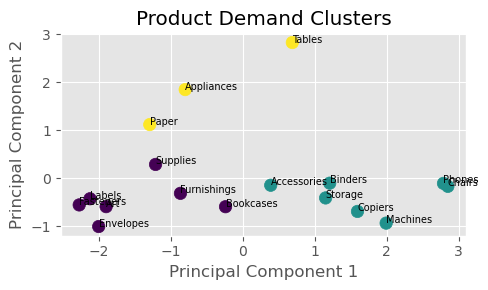

In [80]:
plt.figure(figsize=(5,3))
plt.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["Cluster"],
    cmap="viridis",
    s=80
)
for i in plot_df.index:
    plt.text(
        plot_df.loc[i,"PC1"],
        plot_df.loc[i,"PC2"],
        i,
        fontsize=7
    )
plt.title("Product Demand Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.savefig(
    "charts/product_clusters.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Observation

The K-Means algorithm grouped the product sub-categories into **three distinct demand clusters** based on total sales, average order value, sales volatility, and growth rate. Products within the same cluster exhibit similar sales characteristics and demand behavior.

## Cluster Interpretation

In [81]:
plot_df[["Cluster"]]

,Cluster
Sub-Category,
Accessories,1
Appliances,2
Art,0
Binders,1
Bookcases,0
Chairs,1
Copiers,1
Envelopes,0
Fasteners,0


## Cluster Labels

### Cluster 0 – Low Volume, Stable Demand
Products in this cluster have relatively lower sales volume and lower average order values. These products generally experience stable demand with moderate fluctuations.

### Cluster 1 – High Volume, Stable Demand
Products in this cluster generate consistently high sales and contribute significantly to overall revenue. They represent core products with strong customer demand.

### Cluster 2 – Growing Demand
Products in this cluster exhibit high sales growth rates, indicating increasing customer demand and future business potential.

## Stocking Strategy Recommendation

### Cluster 0 – Low Volume, Stable Demand
Maintain moderate inventory levels and replenish stock based on demand to avoid unnecessary holding costs.

### Cluster 1 – High Volume, Stable Demand
Maintain higher inventory levels and prioritize product availability, as these products contribute significantly to overall sales.

### Cluster 2 – Growing Demand
Increase inventory gradually and monitor demand closely to support future sales growth while avoiding stock shortages.

## Observation

The clustering results show that different product sub-categories have distinct demand patterns. High-demand products require consistent inventory availability, while rapidly growing products should be monitored for increasing stock requirements. Low-volume products can be managed using conservative inventory policies to reduce storage costs.

## Conclusion

K-Means clustering successfully segmented the product sub-categories into three meaningful demand groups. These segments can support inventory planning, demand forecasting, and supply chain decision-making. High-volume products should receive inventory priority, growing-demand products require proactive monitoring, and low-volume products can be stocked more conservatively to optimize operational efficiency.